In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import os

project_folder = "DABA_Return_Validation_Project"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created:", project_folder)

Project folder created: DABA_Return_Validation_Project


In [4]:
import random

random.seed(42)
np.random.seed(42)

n = 500

categories = [
    "Electronics",
    "Clothing",
    "Home Appliances",
    "Beauty",
    "Footwear",
    "Furniture"
]

conditions = [
    "New",
    "Opened",
    "Used",
    "Damaged"
]

reasons = [
    "Damaged Product",
    "Wrong Product",
    "Size Issue",
    "Quality Issue",
    "Changed Mind",
    "Not Needed",
    "Defective Product",
    "Late Delivery"
]

payment_methods = [
    "UPI",
    "Credit Card",
    "Debit Card",
    "Cash on Delivery",
    "Net Banking"
]

data = []

for i in range(1, n + 1):

    category = random.choice(categories)
    condition = random.choice(conditions)
    reason = random.choice(reasons)
    payment = random.choice(payment_methods)

    days_after_delivery = random.randint(1, 30)

    product_price = random.randint(300, 50000)

    customer_rating = random.randint(1, 5)

    previous_returns = random.randint(0, 8)

    damaged = 1 if condition == "Damaged" else 0

    used = 1 if condition == "Used" else 0

    within_policy_period = 1 if days_after_delivery <= 14 else 0

    # Basic return approval logic for synthetic data
    if reason in ["Damaged Product", "Wrong Product", "Defective Product"]:
        approval_probability = 0.80
    elif within_policy_period == 1:
        approval_probability = 0.65
    else:
        approval_probability = 0.25

    if condition == "Used":
        approval_probability -= 0.20

    if condition == "Damaged":
        approval_probability += 0.10

    approval_probability = max(
        0.05,
        min(0.95, approval_probability)
    )

    approved = np.random.binomial(
        1,
        approval_probability
    )

    data.append([
        i,
        category,
        days_after_delivery,
        condition,
        reason,
        payment,
        product_price,
        customer_rating,
        previous_returns,
        within_policy_period,
        approved
    ])

columns = [
    "return_id",
    "product_category",
    "days_after_delivery",
    "product_condition",
    "return_reason",
    "payment_method",
    "product_price",
    "customer_rating",
    "previous_returns",
    "within_policy_period",
    "return_approved"
]

df = pd.DataFrame(
    data,
    columns=columns
)

print("Dataset created successfully!")
print("Number of records:", len(df))

Dataset created successfully!
Number of records: 500


In [5]:
df.head(10)

,return_id,product_category,days_after_delivery,product_condition,return_reason,payment_method,product_price,customer_rating,previous_returns,within_policy_period,return_approved
0,1,Furniture,8,New,Damaged Product,Debit Card,14928,2,1,1,1
1,2,Furniture,1,New,Defective Product,UPI,6440,2,3,1,0
2,3,Footwear,14,New,Quality Issue,Net Banking,14746,4,4,1,0
3,4,Electronics,9,Opened,Defective Product,Debit Card,10489,2,5,1,1
4,5,Electronics,12,New,Defective Product,UPI,22841,5,4,1,1
5,6,Electronics,3,Damaged,Wrong Product,Cash on Delivery,36478,3,5,1,1
6,7,Footwear,22,Opened,Wrong Product,UPI,15235,3,1,0,1
7,8,Clothing,15,New,Defective Product,Debit Card,41960,3,2,0,0
8,9,Home Appliances,23,Used,Quality Issue,Debit Card,45096,1,2,0,0
9,10,Footwear,13,Opened,Size Issue,Cash on Delivery,17991,5,3,1,0


In [6]:
excel_path = "return_dataset.xlsx"

df.to_excel(
    excel_path,
    index=False
)

print("Excel file created successfully!")

Excel file created successfully!


In [7]:
from google.colab import files

files.download("return_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 500
Columns: 11


In [9]:
print(df.columns.tolist())

['return_id', 'product_category', 'days_after_delivery', 'product_condition', 'return_reason', 'payment_method', 'product_price', 'customer_rating', 'previous_returns', 'within_policy_period', 'return_approved']


In [10]:
missing_values = df.isnull().sum()

print(missing_values)

return_id               0
product_category        0
days_after_delivery     0
product_condition       0
return_reason           0
payment_method          0
product_price           0
customer_rating         0
previous_returns        0
within_policy_period    0
return_approved         0
dtype: int64


In [11]:
duplicates = df.duplicated().sum()

print("Duplicate records:", duplicates)

Duplicate records: 0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   return_id             500 non-null    int64 
 1   product_category      500 non-null    object
 2   days_after_delivery   500 non-null    int64 
 3   product_condition     500 non-null    object
 4   return_reason         500 non-null    object
 5   payment_method        500 non-null    object
 6   product_price         500 non-null    int64 
 7   customer_rating       500 non-null    int64 
 8   previous_returns      500 non-null    int64 
 9   within_policy_period  500 non-null    int64 
 10  return_approved       500 non-null    int64 
dtypes: int64(7), object(4)
memory usage: 43.1+ KB


In [13]:
df.describe()

,return_id,days_after_delivery,product_price,customer_rating,previous_returns,within_policy_period,return_approved
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,15.25400,25514.122000,3.060000,3.958000,0.472000,0.558000
std,144.481833,8.73373,14511.906457,1.382832,2.489303,0.499715,0.497122
min,1.000000,1.00000,326.000000,1.000000,0.000000,0.000000,0.000000
25%,125.750000,8.00000,13317.250000,2.000000,2.000000,0.000000,0.000000
50%,250.500000,15.00000,26055.500000,3.000000,4.000000,0.000000,1.000000
75%,375.250000,23.00000,38546.750000,4.000000,6.000000,1.000000,1.000000
max,500.000000,30.00000,49762.000000,5.000000,8.000000,1.000000,1.000000


In [14]:
category_analysis = df.groupby(
    "product_category"
).agg(
    total_requests=("return_id", "count"),
    approved_returns=("return_approved", "sum"),
    average_price=("product_price", "mean"),
    average_previous_returns=("previous_returns", "mean")
)

category_analysis["approval_rate"] = (
    category_analysis["approved_returns"]
    / category_analysis["total_requests"]
    * 100
)

category_analysis = category_analysis.sort_values(
    "approval_rate",
    ascending=False
)

category_analysis

,total_requests,approved_returns,average_price,average_previous_returns,approval_rate
product_category,,,,,
Furniture,77,52,26825.662338,3.831169,67.532468
Electronics,93,52,24293.720430,3.978495,55.913978
Beauty,77,43,26163.610390,3.948052,55.844156
Home Appliances,84,46,25464.857143,4.000000,54.761905
Footwear,86,47,25290.162791,3.569767,54.651163
Clothing,83,39,25344.204819,4.421687,46.987952


In [15]:
category_counts = df[
    "product_category"
].value_counts()

print(category_counts)

product_category
Electronics        93
Footwear           86
Home Appliances    84
Clothing           83
Furniture          77
Beauty             77
Name: count, dtype: int64


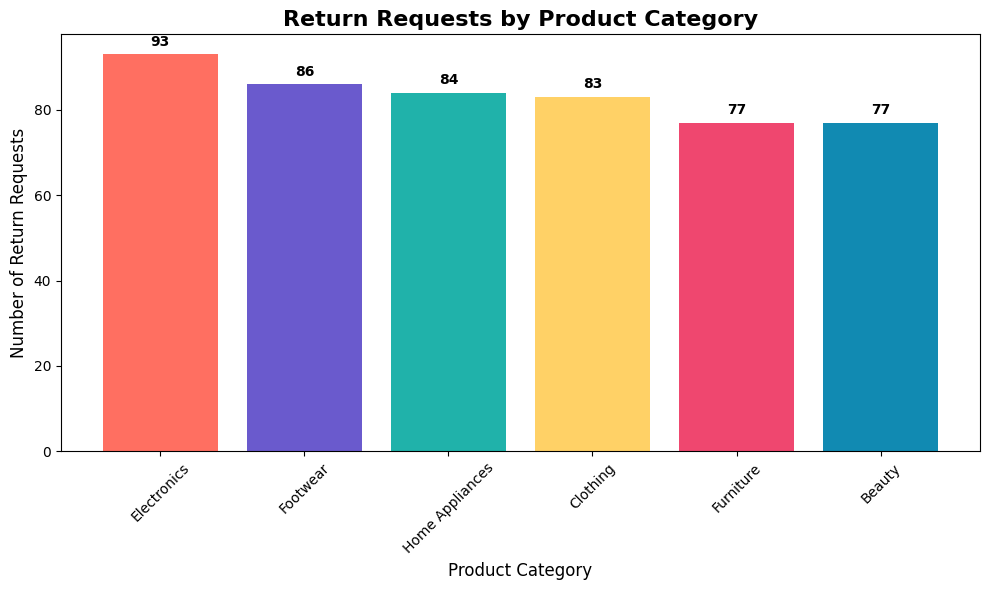

In [16]:
plt.figure(figsize=(10, 6))

category_counts = df["product_category"].value_counts()

bars = plt.bar(
    category_counts.index,
    category_counts.values,
    color=["#FF6F61", "#6A5ACD", "#20B2AA", "#FFD166", "#EF476F", "#118AB2"]
)

plt.title("Return Requests by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Number of Return Requests", fontsize=12)

plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(int(height)),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

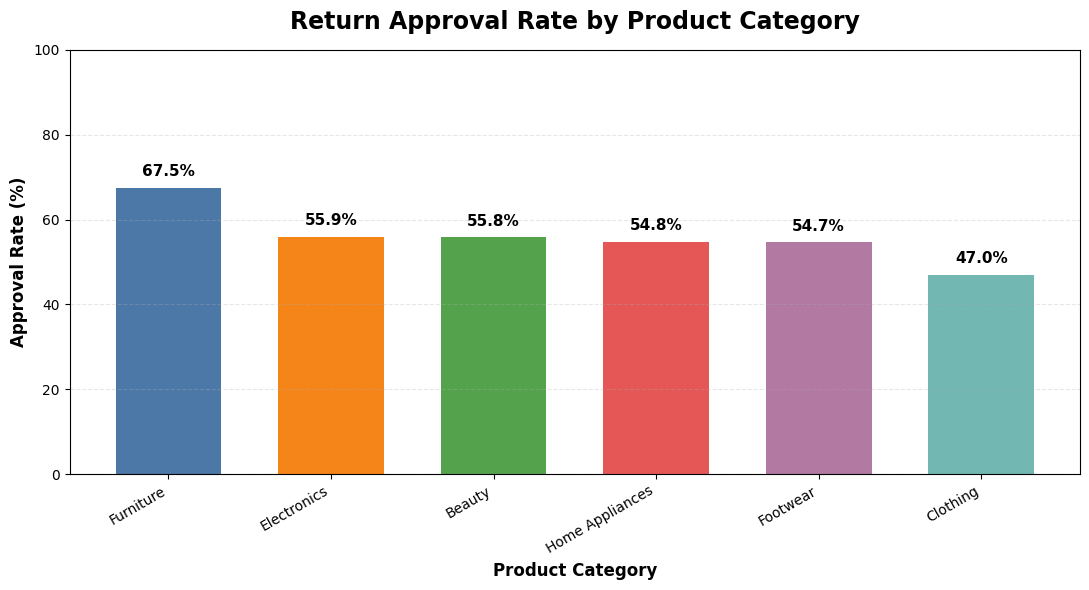

In [17]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    category_analysis.index,
    category_analysis["approval_rate"],
    color=[
        "#4C78A8",
        "#F58518",
        "#54A24B",
        "#E45756",
        "#B279A2",
        "#72B7B2"
    ],
    width=0.65
)

plt.title(
    "Return Approval Rate by Product Category",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Product Category", fontsize=12, fontweight="bold")
plt.ylabel("Approval Rate (%)", fontsize=12, fontweight="bold")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)

# Percentage value on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Professional grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [18]:
reason_analysis = df[
    "return_reason"
].value_counts()

print(reason_analysis)

return_reason
Defective Product    81
Size Issue           72
Wrong Product        69
Not Needed           62
Damaged Product      60
Quality Issue        55
Late Delivery        54
Changed Mind         47
Name: count, dtype: int64


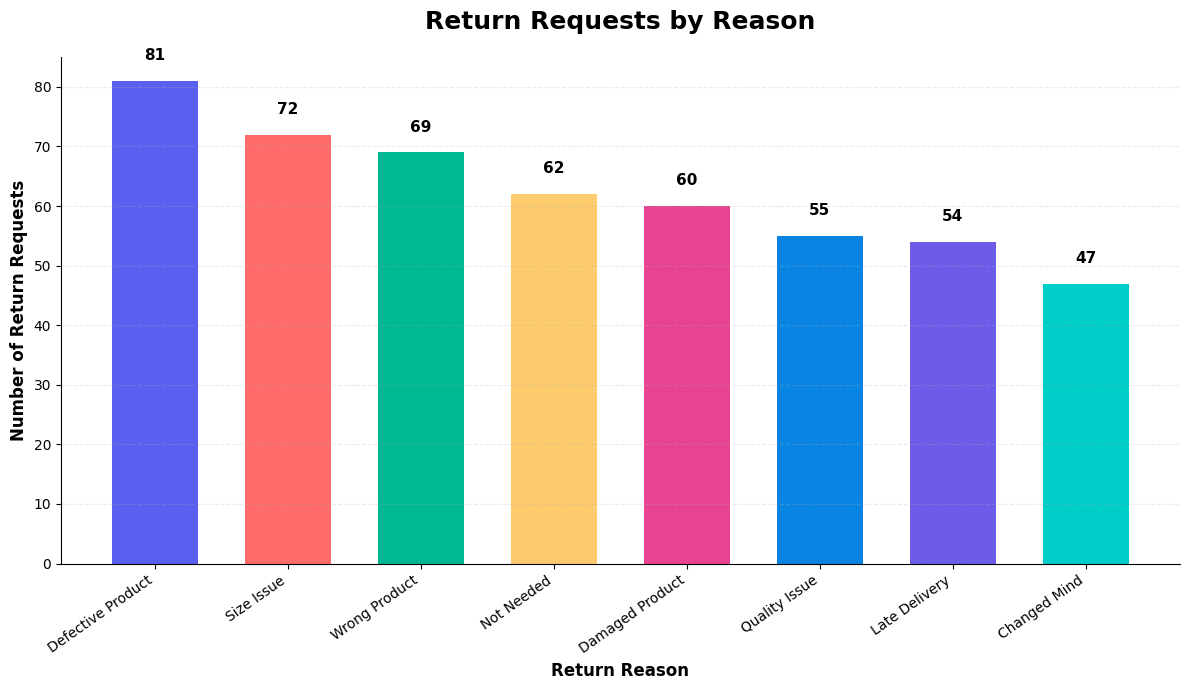

In [20]:
import matplotlib.pyplot as plt

# Count return requests by reason
reason_counts = df["return_reason"].value_counts()

plt.figure(figsize=(12, 7))

bars = plt.bar(
    reason_counts.index,
    reason_counts.values,
    width=0.65,
    color=[
        "#5B5FEF",
        "#FF6B6B",
        "#00B894",
        "#FDCB6E",
        "#E84393",
        "#0984E3",
        "#6C5CE7",
        "#00CEC9"
    ]
)

# Professional title
plt.title(
    "Return Requests by Reason",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Return Reason",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Return Requests",
    fontsize=12,
    fontweight="bold"
)

# Rotate category names
plt.xticks(
    rotation=35,
    ha="right",
    fontsize=10
)

# Show values on top of bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Clean grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
condition_analysis = df.groupby(
    "product_condition"
).agg(
    total_requests=("return_id", "count"),
    approved_returns=("return_approved", "sum")
)

condition_analysis["approval_rate"] = (
    condition_analysis["approved_returns"]
    / condition_analysis["total_requests"]
    * 100
)

condition_analysis

,total_requests,approved_returns,approval_rate
product_condition,,,
Damaged,133,92,69.172932
New,108,70,64.814815
Opened,125,61,48.800000
Used,134,56,41.791045


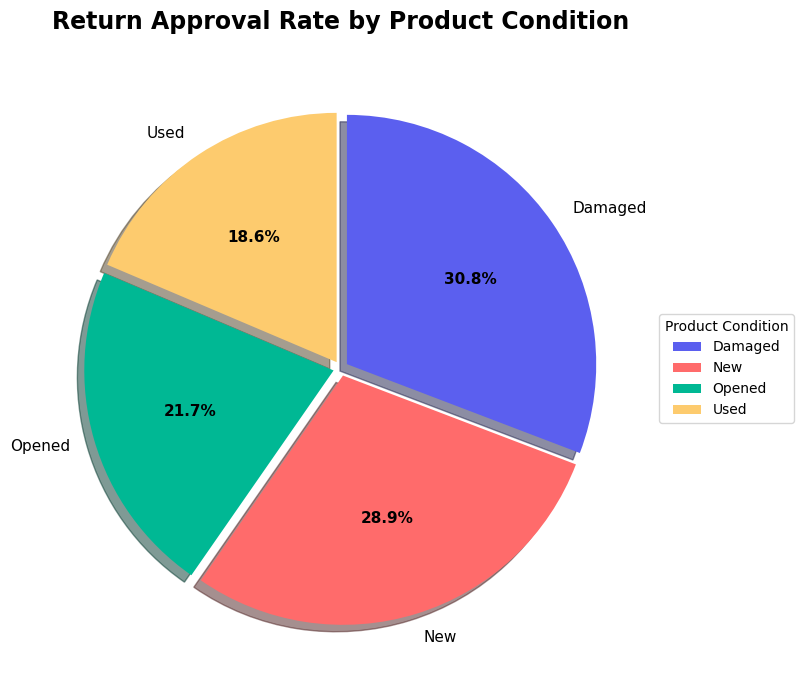

In [22]:
import matplotlib.pyplot as plt

# Approval rate by product condition
condition_data = df.groupby("product_condition")["return_approved"].mean() * 100

plt.figure(figsize=(9, 7))

colors = [
    "#5B5FEF",
    "#FF6B6B",
    "#00B894",
    "#FDCB6E"
]

wedges, texts, autotexts = plt.pie(
    condition_data.values,
    labels=condition_data.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    explode=[0.03] * len(condition_data),
    shadow=True,
    textprops={"fontsize": 11}
)

# Percentage text styling
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

plt.title(
    "Return Approval Rate by Product Condition",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.legend(
    wedges,
    condition_data.index,
    title="Product Condition",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

In [23]:
policy_analysis = df.groupby(
    "within_policy_period"
).agg(
    total_requests=("return_id", "count"),
    approved_returns=("return_approved", "sum")
)

policy_analysis["approval_rate"] = (
    policy_analysis["approved_returns"]
    / policy_analysis["total_requests"]
    * 100
)

policy_analysis

,total_requests,approved_returns,approval_rate
within_policy_period,,,
0,264,118,44.696970
1,236,161,68.220339


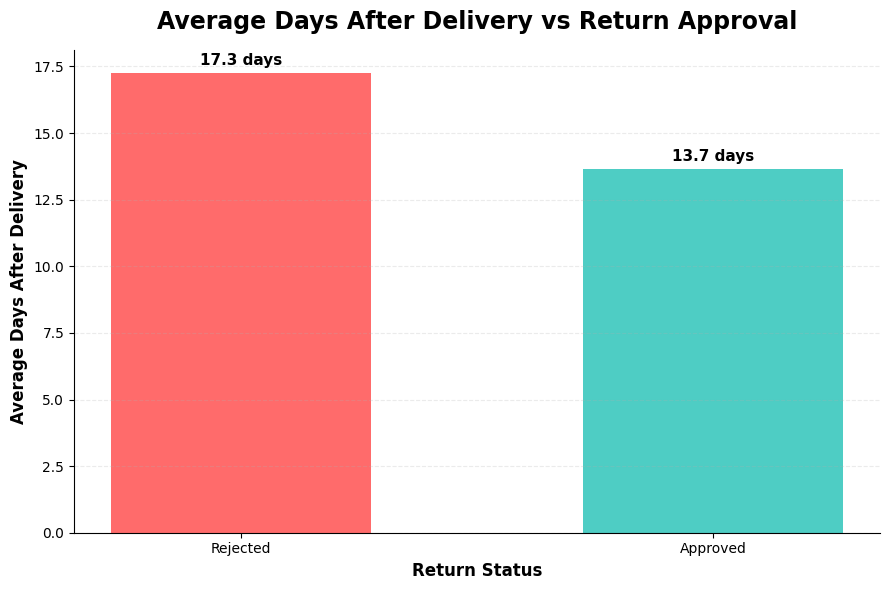

In [24]:
import matplotlib.pyplot as plt

# Average days after delivery for approved and rejected returns
approval_days = df.groupby("return_approved")["days_after_delivery"].mean()

# Change 0 and 1 into readable names
labels = ["Rejected", "Approved"]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    labels,
    approval_days.values,
    color=["#FF6B6B", "#4ECDC4"],
    width=0.55
)

plt.title(
    "Average Days After Delivery vs Return Approval",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Return Status",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Days After Delivery",
    fontsize=12,
    fontweight="bold"
)

# Show values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f} days",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
previous_return_analysis = df.groupby(
    "previous_returns"
)["return_approved"].mean() * 100

previous_return_analysis

,return_approved
previous_returns,
0,50.000000
1,54.166667
2,54.237288
3,61.016949
4,53.125000
5,54.098361
6,63.793103
7,59.183673
8,52.083333


In [26]:
numeric_df = df[
    [
        "days_after_delivery",
        "product_price",
        "customer_rating",
        "previous_returns",
        "within_policy_period",
        "return_approved"
    ]
]

correlation = numeric_df.corr()

correlation

,days_after_delivery,product_price,customer_rating,previous_returns,within_policy_period,return_approved
days_after_delivery,1.000000,0.060053,0.017818,-0.065968,-0.860466,-0.204875
product_price,0.060053,1.000000,0.053803,0.039276,-0.025616,-0.025825
customer_rating,0.017818,0.053803,1.000000,0.065355,-0.017864,-0.031309
previous_returns,-0.065968,0.039276,0.065355,1.000000,0.049800,0.031932
within_policy_period,-0.860466,-0.025616,-0.017864,0.049800,1.000000,0.236461
return_approved,-0.204875,-0.025825,-0.031309,0.031932,0.236461,1.000000


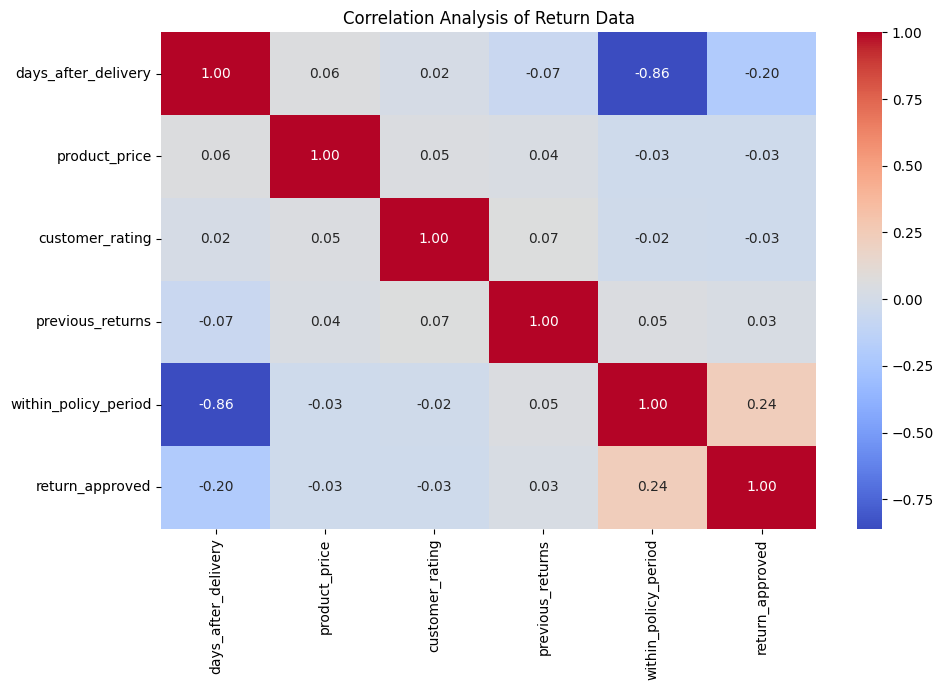

In [27]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Analysis of Return Data"
)

plt.tight_layout()

plt.show()

In [28]:
def calculate_risk_score(row):

    score = 0

    # Days after delivery
    if row["days_after_delivery"] > 14:
        score += 40
    elif row["days_after_delivery"] > 10:
        score += 20

    # Product condition
    if row["product_condition"] == "Used":
        score += 30

    elif row["product_condition"] == "Opened":
        score += 15

    elif row["product_condition"] == "Damaged":
        score += 5

    # Previous returns
    if row["previous_returns"] >= 5:
        score += 20

    elif row["previous_returns"] >= 3:
        score += 10

    # Customer rating
    if row["customer_rating"] <= 2:
        score += 10

    return min(score, 100)

In [29]:
df["risk_score"] = df.apply(
    calculate_risk_score,
    axis=1
)

df.head()

,return_id,product_category,days_after_delivery,product_condition,return_reason,payment_method,product_price,customer_rating,previous_returns,within_policy_period,return_approved,risk_score
0,1,Furniture,8,New,Damaged Product,Debit Card,14928,2,1,1,1,10
1,2,Furniture,1,New,Defective Product,UPI,6440,2,3,1,0,20
2,3,Footwear,14,New,Quality Issue,Net Banking,14746,4,4,1,0,30
3,4,Electronics,9,Opened,Defective Product,Debit Card,10489,2,5,1,1,45
4,5,Electronics,12,New,Defective Product,UPI,22841,5,4,1,1,30


In [30]:
def risk_level(score):

    if score < 30:
        return "LOW"

    elif score < 60:
        return "MEDIUM"

    else:
        return "HIGH"

In [31]:
df["risk_level"] = df[
    "risk_score"
].apply(risk_level)

df.head(10)

,return_id,product_category,days_after_delivery,product_condition,return_reason,payment_method,product_price,customer_rating,previous_returns,within_policy_period,return_approved,risk_score,risk_level
0,1,Furniture,8,New,Damaged Product,Debit Card,14928,2,1,1,1,10,LOW
1,2,Furniture,1,New,Defective Product,UPI,6440,2,3,1,0,20,LOW
2,3,Footwear,14,New,Quality Issue,Net Banking,14746,4,4,1,0,30,MEDIUM
3,4,Electronics,9,Opened,Defective Product,Debit Card,10489,2,5,1,1,45,MEDIUM
4,5,Electronics,12,New,Defective Product,UPI,22841,5,4,1,1,30,MEDIUM
5,6,Electronics,3,Damaged,Wrong Product,Cash on Delivery,36478,3,5,1,1,25,LOW
6,7,Footwear,22,Opened,Wrong Product,UPI,15235,3,1,0,1,55,MEDIUM
7,8,Clothing,15,New,Defective Product,Debit Card,41960,3,2,0,0,40,MEDIUM
8,9,Home Appliances,23,Used,Quality Issue,Debit Card,45096,1,2,0,0,80,HIGH
9,10,Footwear,13,Opened,Size Issue,Cash on Delivery,17991,5,3,1,0,45,MEDIUM


In [32]:
risk_distribution = df[
    "risk_level"
].value_counts()

print(risk_distribution)

risk_level
HIGH      212
MEDIUM    185
LOW       103
Name: count, dtype: int64


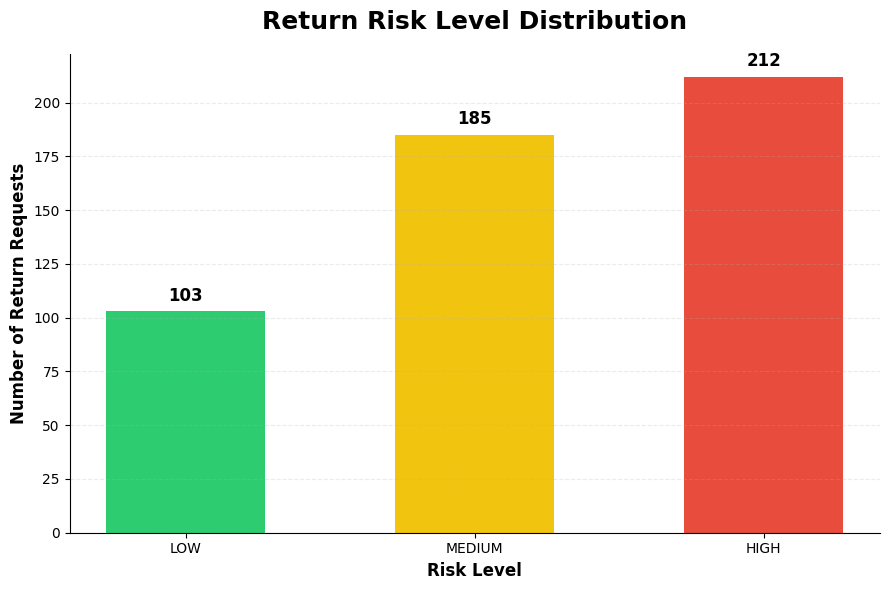

In [33]:
import matplotlib.pyplot as plt

# Count each risk level
risk_distribution = df["risk_level"].value_counts()

# Keep the order: LOW, MEDIUM, HIGH
risk_distribution = risk_distribution.reindex(
    ["LOW", "MEDIUM", "HIGH"]
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    risk_distribution.index,
    risk_distribution.values,
    width=0.55,
    color=["#2ECC71", "#F1C40F", "#E74C3C"]
)

plt.title(
    "Return Risk Level Distribution",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Return Requests",
    fontsize=12,
    fontweight="bold"
)

# Display number on top of each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Clean professional grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
high_risk_analysis = df.groupby(
    "product_category"
).agg(
    total_requests=("return_id", "count"),
    average_risk_score=("risk_score", "mean"),
    high_risk_cases=(
        "risk_level",
        lambda x: (x == "HIGH").sum()
    )
)

high_risk_analysis[
    "high_risk_percentage"
] = (
    high_risk_analysis["high_risk_cases"]
    / high_risk_analysis["total_requests"]
    * 100
)

high_risk_analysis = high_risk_analysis.sort_values(
    "high_risk_percentage",
    ascending=False
)

high_risk_analysis

,total_requests,average_risk_score,high_risk_cases,high_risk_percentage
product_category,,,,
Electronics,93,52.956989,42,45.161290
Clothing,83,52.409639,37,44.578313
Beauty,77,53.961039,34,44.155844
Home Appliances,84,50.773810,36,42.857143
Furniture,77,50.584416,31,40.259740
Footwear,86,48.953488,32,37.209302


In [35]:
top_risk_category = high_risk_analysis.index[0]

print(
    "Highest High-Risk Category:",
    top_risk_category
)

Highest High-Risk Category: Electronics


In [36]:
dataset_path = (
    f"{project_folder}/return_dataset.csv"
)

df.to_csv(
    dataset_path,
    index=False
)

print(
    "Dataset saved at:",
    dataset_path
)

Dataset saved at: DABA_Return_Validation_Project/return_dataset.csv


In [37]:
analysis_path = (
    f"{project_folder}/category_risk_analysis.csv"
)

high_risk_analysis.to_csv(
    analysis_path
)

print(
    "Risk analysis saved at:",
    analysis_path
)

Risk analysis saved at: DABA_Return_Validation_Project/category_risk_analysis.csv


In [38]:
from google.colab import files

files.download(
    dataset_path
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
print("=" * 65)
print("        DABA PROJECT - DAY 1 SUMMARY")
print("=" * 65)

print("\nProject:")
print("Explainable LLM-Based Return Validation and Risk Assessment")

print("\nDataset Information")
print("-" * 65)

print("Total Return Records       :", len(df))

print(
    "Product Categories         :",
    df["product_category"].nunique()
)

print(
    "Return Reasons             :",
    df["return_reason"].nunique()
)

print(
    "Risk Levels                :",
    df["risk_level"].nunique()
)

print("\nRisk Distribution")
print("-" * 65)

risk_counts = df["risk_level"].value_counts()

for level in ["LOW", "MEDIUM", "HIGH"]:
    print(f"{level:<12} : {risk_counts.get(level, 0)} cases")

print("\nHighest High-Risk Category")
print("-" * 65)

print("Category:", top_risk_category)

print("\nDay 1 Outcome")
print("-" * 65)

print("✓ Dataset created")
print("✓ Exploratory Data Analysis completed")
print("✓ Risk score calculated")
print("✓ Risk levels assigned")
print("✓ High-risk category identified")

print("\n" + "=" * 65)
print("        DAY 1 COMPLETED SUCCESSFULLY!")
print("=" * 65)

        DABA PROJECT - DAY 1 SUMMARY

Project:
Explainable LLM-Based Return Validation and Risk Assessment

Dataset Information
-----------------------------------------------------------------
Total Return Records       : 500
Product Categories         : 6
Return Reasons             : 8
Risk Levels                : 3

Risk Distribution
-----------------------------------------------------------------
LOW          : 103 cases
MEDIUM       : 185 cases
HIGH         : 212 cases

Highest High-Risk Category
-----------------------------------------------------------------
Category: Electronics

Day 1 Outcome
-----------------------------------------------------------------
✓ Dataset created
✓ Exploratory Data Analysis completed
✓ Risk score calculated
✓ Risk levels assigned
✓ High-risk category identified

        DAY 1 COMPLETED SUCCESSFULLY!
